
# 00 — การสำรวจข้อมูล (Exploratory Data Analysis)

**โปรเจค:** แบบจำลอง CNN + Transfer Learning + Data Augmentation สำหรับรู้จำตัวอักษร/ตัวเลขภาษาไทย

หมายเหตุสำคัญเกี่ยวกับขอบเขตข้อมูล (โปรดอ่านก่อน)
---
โจทย์ต้นฉบับระบุว่าชุดข้อมูลมี **72 คลาส** แต่ชุดข้อมูลจริงที่ได้รับมา (โฟลเดอร์ `round2/`) มีเพียง **31 โฟลเดอร์คลาส** เท่านั้น (ตั้งชื่อเป็นตัวเลข เช่น `161`, `185`, `193`, ... ไม่เรียงต่อเนื่องกัน) และ**ไม่มีไฟล์ label mapping ใด ๆ** ที่จะบอกว่าตัวเลขโฟลเดอร์แต่ละอันตรงกับตัวอักษร/ตัวเลขไทยตัวใด

ทีมงานตัดสินใจ **ไม่สมมติชื่อภาษาไทยขึ้นเองให้แต่ละโฟลเดอร์** เพราะจะทำให้เกิด label ที่ผิดพลาดในชุดข้อมูลจริงที่ต้องส่งตรวจ ดังนั้นตลอดทั้งโปรเจคนี้:

- เราปฏิบัติต่อ **ชื่อโฟลเดอร์ (ตัวเลข) เป็น class ID** โดยตรง (เช่น class `161`, class `193`)
- โมเดลจะทำนายเป็น **31 คลาส** ตามข้อมูลจริงที่มี ไม่ใช่ 72 คลาสตามโจทย์ตั้งต้น
- หากภายหลังได้ไฟล์ mapping จริง (โฟลเดอร์ → อักษรไทย) สามารถเติมลงใน `CLASS_ID_TO_THAI` ในไฟล์ `src/data_utils.py` ได้ทันที โดยไม่ต้องแก้โค้ดส่วนอื่นเลย เพราะทุกอย่างอ้างอิงด้วย `class_id`

การตัดสินใจนี้เป็นไปตามหลักการ "ห้ามสมมติข้อมูลที่ไม่มีหลักฐานรองรับ" — ดูรายละเอียดเพิ่มเติมใน `README.md` หัวข้อ "ข้อจำกัดของชุดข้อมูล"


In [1]:

%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from src.data_utils import list_images, class_counts_table, DATA_ROOT
from src.viz_utils import plot_class_distribution, show_image_grid

pd.set_option("display.max_rows", 40)
print("Dataset root:", DATA_ROOT)


Dataset root: C:\Users\Acer\Desktop\deep\round2


## 1. ภาพรวมของชุดข้อมูล

In [2]:

df = list_images()
n_images = len(df)
n_classes = df["class_id"].nunique()
print(f"จำนวนภาพทั้งหมด: {n_images:,} ภาพ")
print(f"จำนวนคลาสทั้งหมด: {n_classes} คลาส (folder IDs ใน round2/)")
df.head()


จำนวนภาพทั้งหมด: 30,002 ภาพ
จำนวนคลาสทั้งหมด: 31 คลาส (folder IDs ใน round2/)


,filepath,class_id,filename
0,C:\Users\Acer\Desktop\deep\round2\161\bc_001sg...,161,bc_001sg_3_118.jpg
1,C:\Users\Acer\Desktop\deep\round2\161\bc_001sg...,161,bc_001sg_3_140.jpg
2,C:\Users\Acer\Desktop\deep\round2\161\bc_001sg...,161,bc_001sg_3_142.jpg
3,C:\Users\Acer\Desktop\deep\round2\161\bc_001sg...,161,bc_001sg_3_32.jpg
4,C:\Users\Acer\Desktop\deep\round2\161\bc_001sg...,161,bc_001sg_3_42.jpg



**สรุป:** ชุดข้อมูลมีทั้งหมด 30,002 ภาพ กระจายอยู่ใน 31 คลาส (folder ID) ซึ่งน้อยกว่า 72 คลาสตามที่ระบุในโจทย์ต้นฉบับตามที่อธิบายไว้ข้างต้น


## 2. จำนวนข้อมูลต่อคลาส (Class Distribution) — ตารางและกราฟ

In [3]:

counts = class_counts_table(df)
counts.columns = ["class_id", "จำนวนภาพ"]
counts


,class_id,จำนวนภาพ
0,185,4863
1,193,3306
2,194,2197
3,180,2025
4,161,1951
5,186,1889
6,183,1745
7,181,1662
8,164,1448
9,162,1355


In [4]:

print("คลาสที่มีข้อมูลมากที่สุด 5 อันดับแรก:")
display(counts.head(5))
print("\nคลาสที่มีข้อมูลน้อยที่สุด 5 อันดับแรก:")
display(counts.tail(5))

imbalance_ratio = counts["จำนวนภาพ"].max() / counts["จำนวนภาพ"].min()
print(f"\nอัตราส่วนความไม่สมดุล (max/min) = {imbalance_ratio:,.0f} เท่า")
print(f"ค่ามัธยฐาน (median) จำนวนภาพต่อคลาส = {counts['จำนวนภาพ'].median():.0f}")


คลาสที่มีข้อมูลมากที่สุด 5 อันดับแรก:


,class_id,จำนวนภาพ
0,185,4863
1,193,3306
2,194,2197
3,180,2025
4,161,1951



คลาสที่มีข้อมูลน้อยที่สุด 5 อันดับแรก:


,class_id,จำนวนภาพ
26,169,43
27,189,39
28,175,32
29,177,1
30,163,1



อัตราส่วนความไม่สมดุล (max/min) = 4,863 เท่า
ค่ามัธยฐาน (median) จำนวนภาพต่อคลาส = 435


C:\Users\Acer\Desktop\deep\src\viz_utils.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, x="class_id", y="count", order=counts_df["class_id"], palette=PALETTE, ax=ax)


Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\00_class_distribution.png


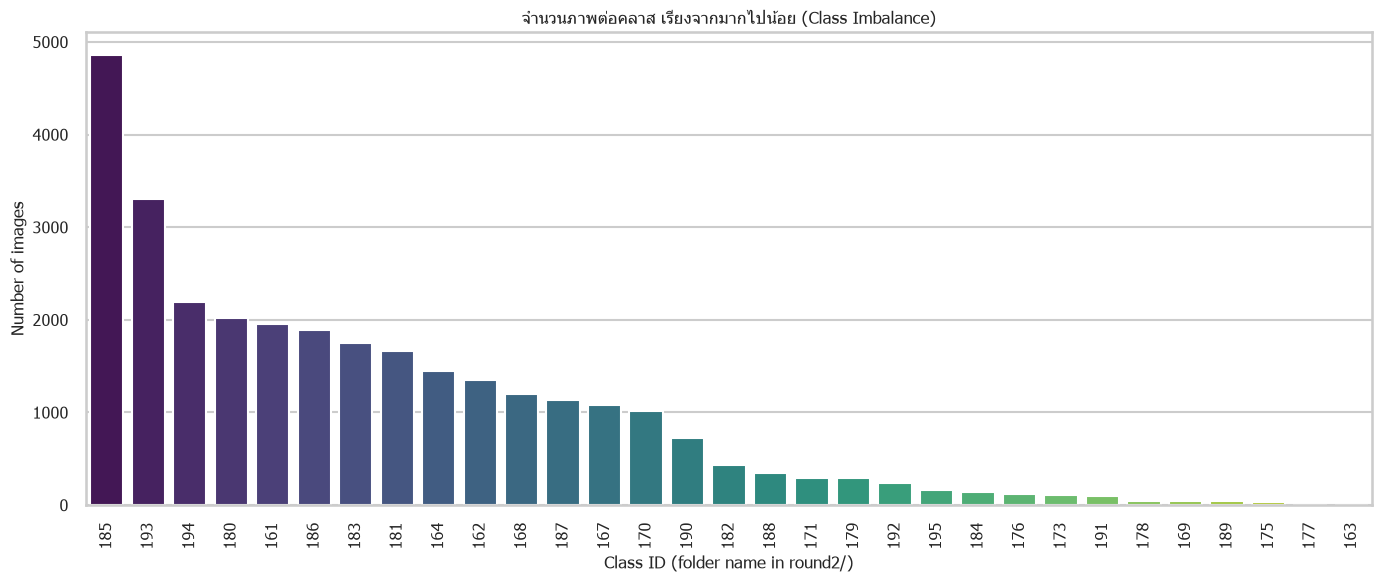

In [5]:

plot_counts = class_counts_table(df)  # unrenamed columns for the plot helper
fig = plot_class_distribution(plot_counts)



**ข้อสังเกต:** ชุดข้อมูลนี้มีความไม่สมดุลระหว่างคลาสสูงมาก — คลาสที่มีข้อมูลมากที่สุดมีภาพมากกว่าคลาสที่น้อยที่สุดหลายพันเท่า และมีคลาส 2 คลาส (`163`, `177`) ที่มีภาพเพียง**คลาสละ 1 ภาพเท่านั้น** ซึ่งเป็นกรณีร้ายแรงที่ต้องจัดการเป็นพิเศษตอนแบ่ง Train/Validation (ดู notebook `01_preprocessing_augmentation.ipynb`)


## 3. ตัวอย่างภาพจริงจากชุดข้อมูล

Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\00_sample_images_grid.png


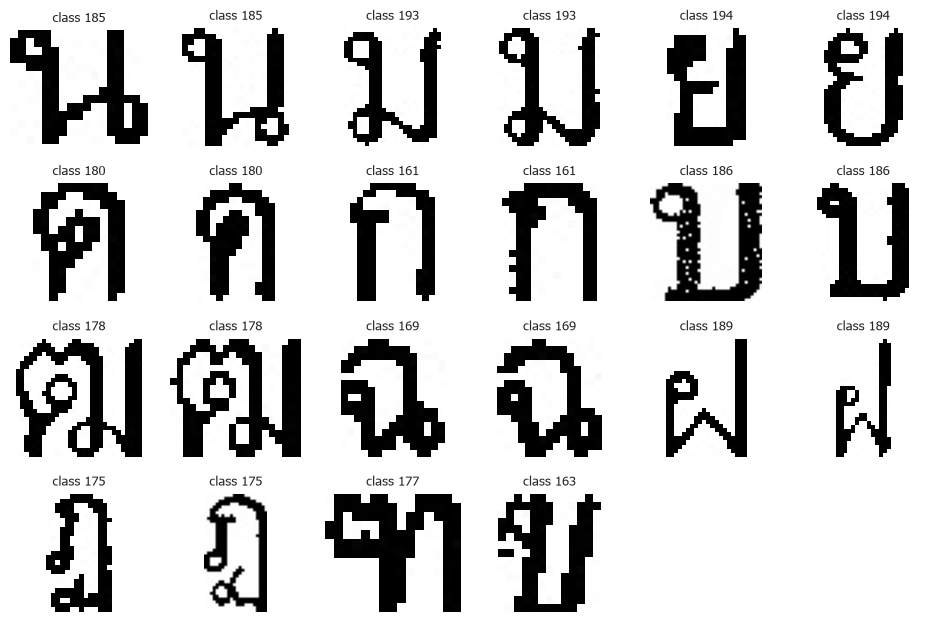

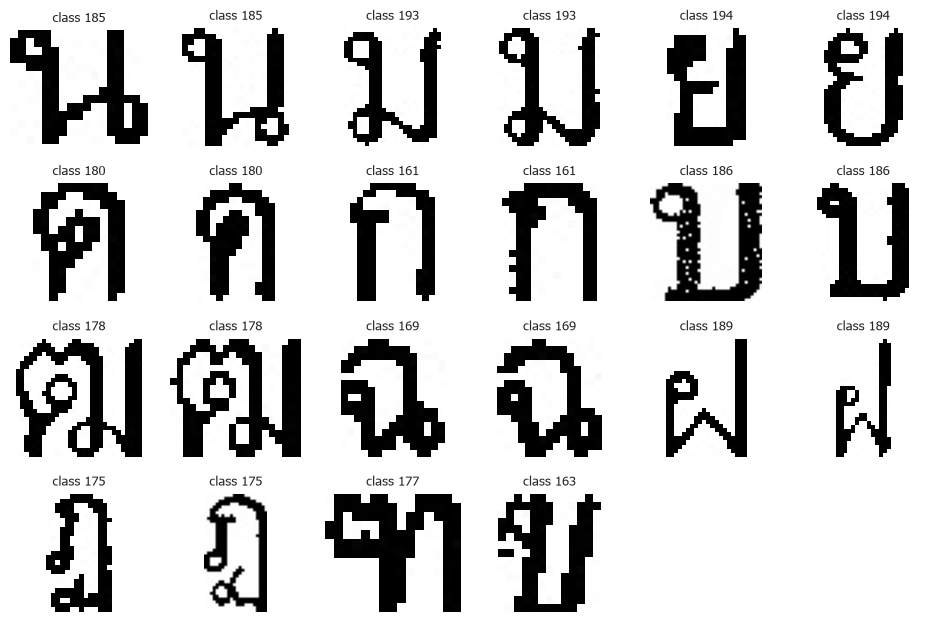

In [6]:

rng = np.random.RandomState(7)
sample_classes = list(counts["class_id"].head(6)) + list(counts["class_id"].tail(6))
imgs, titles = [], []
for cid in sample_classes:
    sub = df[df["class_id"] == cid]
    pick = sub.sample(min(2, len(sub)), random_state=7)
    for _, row in pick.iterrows():
        with Image.open(row["filepath"]) as im:
            imgs.append(np.array(im.convert("RGB")))
            titles.append(f"class {cid}")

show_image_grid(imgs, titles, ncols=6, name="00_sample_images_grid.png", figsize_scale=1.6)



สังเกตว่าภาพทุกภาพเป็นภาพขาวดำ (grayscale) ตัวอักษร/ตัวเลขสีเข้มบนพื้นหลังสีอ่อน ตัดขอบมาแล้วเฉพาะบริเวณตัวอักษร ขนาดภาพเล็กมากและมีสัดส่วนกว้าง/ยาวไม่เท่ากันในแต่ละภาพ


## 4. คุณสมบัติของภาพ: ขนาดและโหมดสี

In [7]:

rng = np.random.RandomState(0)
sample_df = df.sample(3000, random_state=0)
widths, heights, modes = [], [], []
for fp in sample_df["filepath"]:
    with Image.open(fp) as im:
        w, h = im.size
        widths.append(w); heights.append(h); modes.append(im.mode)

widths = np.array(widths); heights = np.array(heights)
from collections import Counter
mode_counts = Counter(modes)

print(f"สุ่มตรวจสอบ {len(sample_df)} ภาพจากทั้งหมด {len(df)} ภาพ")
print(f"ความกว้าง (width):  min={widths.min()}, median={np.median(widths):.0f}, mean={widths.mean():.1f}, max={widths.max()}")
print(f"ความสูง (height):   min={heights.min()}, median={np.median(heights):.0f}, mean={heights.mean():.1f}, max={heights.max()}")
print(f"โหมดสี (color mode) ที่พบ: {dict(mode_counts)}  (L = grayscale 8-bit)")


สุ่มตรวจสอบ 3000 ภาพจากทั้งหมด 30002 ภาพ
ความกว้าง (width):  min=6, median=17, mean=18.0, max=49
ความสูง (height):   min=9, median=21, mean=22.1, max=66
โหมดสี (color mode) ที่พบ: {'L': 3000}  (L = grayscale 8-bit)


Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\00_image_size_distribution.png


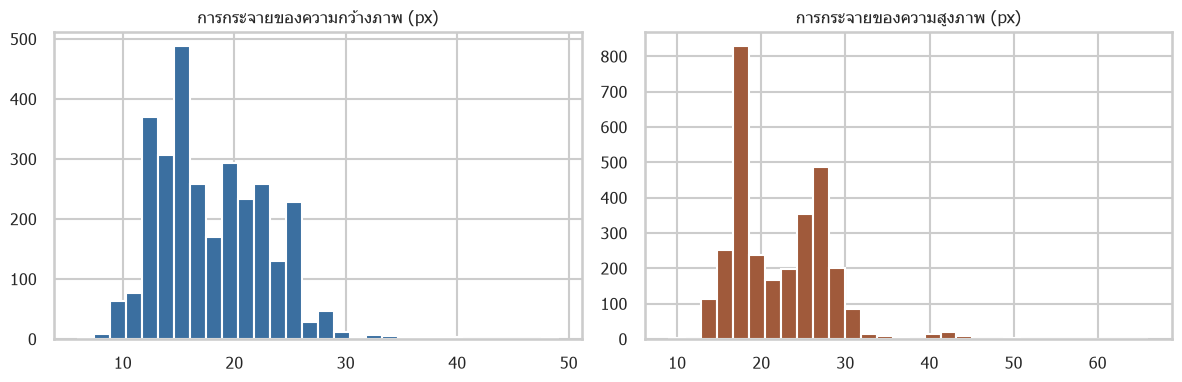

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="#3b6fa0")
axes[0].set_title("การกระจายของความกว้างภาพ (px)")
axes[1].hist(heights, bins=30, color="#a05a3b")
axes[1].set_title("การกระจายของความสูงภาพ (px)")
fig.tight_layout()
from src.viz_utils import savefig
savefig(fig, "00_image_size_distribution.png")
plt.show()



**ข้อสังเกต:** ภาพทั้งหมดเป็น **grayscale (โหมด `L`)** และมีขนาดเล็กมาก (กว้าง/สูงเพียงหลักสิบพิกเซล มัธยฐานประมาณ 17×21 พิกเซล) ซึ่งเล็กกว่า input size ทั่วไปของโมเดล pretrained บน ImageNet (เช่น 96×96 หรือ 224×224) มาก การขยายภาพขึ้น (upscale) จะทำให้เกิด blur/interpolation artifact ซึ่งเป็นความท้าทายที่ต้องพิจารณาในขั้นตอนเตรียมข้อมูล


## 5. วิเคราะห์ความท้าทายของชุดข้อมูลนี้ (Challenges Analysis)


### 5.1 ความไม่สมดุลของจำนวนข้อมูลต่อคลาส (Class Imbalance) — รุนแรงมาก
ดังที่แสดงในหัวข้อ 2 คลาสที่มีข้อมูลมากที่สุด (`185`, 4,863 ภาพ) มีจำนวนมากกว่าคลาสที่มีข้อมูลน้อยที่สุด (`163`/`177`, 1 ภาพ) หลายพันเท่า และมีถึง 2 คลาสที่มีข้อมูลเพียง 1 ภาพ ซึ่งไม่เพียงพอต่อการเรียนรู้ pattern ใด ๆ อย่างมีนัยสำคัญ และเป็นไปไม่ได้เลยที่จะแบ่งข้อมูลของคลาสเหล่านี้ให้อยู่ทั้งใน Train และ Validation พร้อมกัน — เราจัดการเรื่องนี้ด้วยกฎการแบ่งข้อมูลแบบพิเศษใน notebook `01`

### 5.2 ความหลากหลายของลายมือ/แหล่งที่มาของตัวอย่าง


In [9]:

import re
pattern = re.compile(r"^([a-z]{2}_\d{3}[a-z]{2})_")
df["writer_code"] = df["filename"].str.extract(pattern)
n_unmatched = df["writer_code"].isna().sum()
n_unique_writers = df["writer_code"].nunique()
print(f"จำนวนรหัสผู้เขียน/รอบเก็บข้อมูลที่แยกได้จากชื่อไฟล์ (เช่น 'bc_001sg'): {n_unique_writers} รหัส")
print(f"ชื่อไฟล์ที่แยกรหัสไม่ได้: {n_unmatched} ไฟล์ (จาก {len(df)})")

writers_per_class = df.groupby("class_id")["writer_code"].nunique().sort_values()
print("\nคลาสที่มีความหลากหลายของแหล่งที่มาน้อยที่สุด (writer code นับได้น้อย):")
display(writers_per_class.head(5))
print("คลาสที่มีความหลากหลายมากที่สุด:")
display(writers_per_class.tail(5))


จำนวนรหัสผู้เขียน/รอบเก็บข้อมูลที่แยกได้จากชื่อไฟล์ (เช่น 'bc_001sg'): 102 รหัส
ชื่อไฟล์ที่แยกรหัสไม่ได้: 0 ไฟล์ (จาก 30002)

คลาสที่มีความหลากหลายของแหล่งที่มาน้อยที่สุด (writer code นับได้น้อย):


class_id
163     1
177     1
195     8
175    14
189    21
Name: writer_code, dtype: int64

คลาสที่มีความหลากหลายมากที่สุด:


class_id
186    100
194    100
181    101
183    102
185    102
Name: writer_code, dtype: int64


**ข้อสังเกต:** ชื่อไฟล์ในชุดข้อมูลมีรูปแบบสม่ำเสมอ (เช่น `bc_001sg_3_118.jpg`) ซึ่งสามารถแยกส่วนต้นออกมาเป็น "รหัสที่คาดว่าเป็นผู้เขียนหรือรอบการเก็บข้อมูล" ได้ครบทุกไฟล์ พบว่ามีรหัสไม่ซ้ำกันมากถึง 102 รหัส บ่งชี้ว่าข้อมูลถูกเก็บมาจากหลายคน/หลายรอบ ซึ่งควรทำให้มีความหลากหลายของลายมือสูง — **แต่ความหลากหลายนี้ไม่กระจายเท่ากันทุกคลาส**: คลาสที่มีจำนวนภาพน้อย (เช่น `163`, `177`) ก็มีจำนวนรหัสผู้เขียนน้อยตามไปด้วย (1 รหัสเท่านั้น) หมายความว่าคลาสเหล่านี้ไม่ได้แค่ "มีข้อมูลน้อย" แต่ยัง "ขาดความหลากหลายของสไตล์การเขียน" ไปพร้อมกัน ซึ่งซ้ำเติมปัญหาการเรียนรู้ของโมเดลในคลาสส่วนน้อยให้หนักขึ้นไปอีก

### 5.3 ความคล้ายคลึงกันระหว่างคลาส (Visual Similarity)
เนื่องจากชุดข้อมูลนี้ไม่มีชื่ออักษรไทยกำกับ (มีแต่ folder ID) เราจึงไม่สามารถระบุล่วงหน้าได้อย่างแม่นยำว่าคลาสใดคืออักษรที่รูปร่างคล้ายกัน (เช่นในภาษาไทยที่ทราบกันดีว่า ป/ฝ, ถ/ภ, ฎ/ฏ มีรูปทรงใกล้เคียงกันมาก) แต่จากตัวอย่างภาพในหัวข้อ 3 จะเห็นได้ว่าภาพหลายคลาสมีลักษณะเป็นเส้นโค้ง/หยักที่คล้ายกันในสายตามนุษย์ที่ไม่คุ้นเคย เราจะ**วัดความคล้ายคลึงนี้เชิงปริมาณจริง**ด้วย Confusion Matrix ใน notebook `04_evaluation_prediction.ipynb` ซึ่งจะชี้ชัดว่าคู่คลาสใดที่โมเดลสับสนกันบ่อยที่สุด

### 5.4 ขนาดภาพต้นฉบับเล็กมากและมีสัญญาณรบกวนจากการขยายภาพ
ตามที่แสดงในหัวข้อ 4 ภาพต้นฉบับมีขนาดเพียงหลักสิบพิกเซล (มัธยฐาน ~17×21 พิกเซล) การขยายภาพให้เข้ากับ input size ของ backbone pretrained (96×96) จะทำให้เกิดการ interpolate ซึ่งทำให้เส้นขอบตัวอักษรเบลอ/เป็นบั้ง ส่งผลให้รายละเอียดเล็ก ๆ ที่ใช้แยกแยะอักษรที่คล้ายกัน (เช่น ตำแหน่งจุด/หาง) อาจสูญหายไปบางส่วน

### 5.5 ภาพเป็น grayscale แต่โมเดล pretrained ต้องการ 3 ช่องสัญญาณ (RGB)
โมเดล backbone ที่ pretrained บน ImageNet (MobileNetV2, EfficientNetB0 ฯลฯ) รับ input เป็นภาพ 3 channel (RGB) แต่ภาพในชุดข้อมูลนี้เป็น grayscale ล้วน (โหมด `L`) จึงต้องแปลงเป็น 3 channel ก่อน (โดย stack ช่องเดียวกันซ้ำ 3 ครั้ง) ซึ่งจัดการในขั้นตอนเตรียมข้อมูล (notebook `01`)

### 5.6 ไม่มีไฟล์ label mapping (โฟลเดอร์ → อักษรไทยจริง)
ตามที่อธิบายไว้ตอนต้นของ notebook นี้ — เป็นข้อจำกัดด้านความสมบูรณ์ของชุดข้อมูลที่ได้รับ มากกว่าความท้าทายเชิงโมเดล แต่ส่งผลให้การรายงานผลทั้งหมดในโปรเจคนี้ต้องอ้างอิงด้วย class ID แทนชื่ออักษรไทยจริง



## 6. สรุป EDA

| ประเด็น | ค่าที่พบจริง |
|---|---|
| จำนวนภาพทั้งหมด | 30,002 |
| จำนวนคลาส | 31 (ไม่ใช่ 72 ตามโจทย์ต้นฉบับ — ดูหมายเหตุด้านบน) |
| จำนวนภาพต่อคลาส (min / median / max) | 1 / ~439 / 4,863 |
| จำนวนคลาสที่มีภาพเพียง 1 ภาพ | 2 คลาส (163, 177) |
| ขนาดภาพ (median) | ~17×21 พิกเซล, grayscale |
| จำนวนรหัสผู้เขียน/รอบเก็บข้อมูลที่พบ | 102 รหัส (กระจายไม่เท่ากันในแต่ละคลาส) |

ผลการสำรวจนี้กำหนดทิศทางของขั้นตอนถัดไปโดยตรง: ต้องมีกลยุทธ์แบ่งข้อมูลที่รองรับคลาสขนาดเล็กมาก (notebook 01), ต้องใช้ Data Augmentation ที่ไม่ทำลายความหมายของตัวอักษร (ห้าม flip), ต้องมีเทคนิคจัดการ class imbalance ตอนเทรน (Focal Loss, notebook 02–03), และต้องใช้ Transfer Learning เพื่อชดเชยข้อมูลที่มีจำกัดต่อคลาส (notebook 02)
